# Superstore Dataset


## Task 1: Load & Explore Data

We start by importing our libraries, loading the dataset, and getting a feel for its structure — shape, column types, and summary statistics.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Shape: 9,994 rows × 21 columns


In [3]:
# First 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
# Summary statistics for numeric columns
df.describe().round(2)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


> **Insight:** The dataset has 9,994 rows and 21 columns. Sales range from ~\$0.44 to ~\$22,638, with a mean of ~\$229. Profit ranges from negative (losses) to over \$8,000. This variation will be important to investigate.

## Task 2: Data Cleaning

Check for missing values, handle them appropriately, and convert columns to their correct data types.

In [8]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
Series([], dtype: int64)

Total missing values: 0


In [9]:
# Convert date columns from string to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

In [10]:
print("Date columns converted:")
print(df[['Order Date', 'Ship Date']].dtypes)
print()
print("Sample dates:")
print(df[['Order Date', 'Ship Date']].head(3))

Date columns converted:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

Sample dates:
  Order Date  Ship Date
0 2016-11-08 2016-11-11
1 2016-11-08 2016-11-11
2 2016-06-12 2016-06-16


> **Insight:** The dataset is very clean. Date columns were stored as strings and needed to be converted to `datetime` for time-series analysis.

## Task 3: Feature Engineering

Create new columns to enable richer analysis: time-based features and a calculated profit metric.

In [15]:
# Extract time components from Order Date
df['Order Month'] = df['Order Date'].dt.month
df['Order Year']  = df['Order Date'].dt.year
df['YearMonth']   = df['Order Date'].dt.to_period('M')

In [16]:
# Shipping duration in days
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [20]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,YearMonth,Shipping Days,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,2016-11,3,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,2016-11,3,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,2016-06,4,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,2015-10,7,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,2015-10,7,0.1125


In [18]:
# Profit Margin = Profit / Sales
df['Profit Margin'] = df['Profit'] / df['Sales']

print("New columns created: Order Month, Order Year, YearMonth, Shipping Days, Profit Margin")
print()
print("Profit Margin stats:")
print(df['Profit Margin'].describe().round(4))

New columns created: Order Month, Order Year, YearMonth, Shipping Days, Profit Margin

Profit Margin stats:
count    9994.0000
mean        0.1203
std         0.4668
min        -2.7500
25%         0.0750
50%         0.2700
75%         0.3625
max         0.5000
Name: Profit Margin, dtype: float64


In [21]:
# Verify Profit Margin is logically correct (should mostly be between -1 and 1)
outside_range = df[(df['Profit Margin'] < -1) | (df['Profit Margin'] > 1)].shape[0]
print(f"Rows with margin outside [-1, 1]: {outside_range}")
print(f"Average Profit Margin: {df['Profit Margin'].mean():.2%}")
print(f"Median Profit Margin: {df['Profit Margin'].median():.2%}")

Rows with margin outside [-1, 1]: 349
Average Profit Margin: 12.03%
Median Profit Margin: 27.00%


> **Insight:** The average profit margin is ~12.03%, but there is a wide range — some products are deeply discounted, leading to negative margins. `Shipping Days` typically ranges 1–7 days depending on ship mode.

## Task 4: GroupBy & Aggregation

Use GroupBy to compute summary statistics by category, region, customer, and time.

In [22]:
# Total sales by category
sales_by_cat = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Total Sales by Category:")
print(sales_by_cat.apply(lambda x: f"${x:,.0f}"))

Total Sales by Category:
Category
Technology         $836,154
Furniture          $742,000
Office Supplies    $719,047
Name: Sales, dtype: object


In [23]:
# Total profit by region
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("Total Profit by Region:")
print(profit_by_region.apply(lambda x: f"${x:,.0f}"))

Total Profit by Region:
Region
West       $108,418
East        $91,523
South       $46,749
Central     $39,706
Name: Profit, dtype: object


In [24]:
# Top 5 customers by sales
top5_customers = (df.groupby('Customer Name')['Sales']
                   .sum()
                   .sort_values(ascending=False)
                   .head(5))
print("Top 5 Customers by Sales:")
print(top5_customers.apply(lambda x: f"${x:,.0f}"))

Top 5 Customers by Sales:
Customer Name
Sean Miller      $25,043
Tamara Chand     $19,052
Raymond Buch     $15,117
Tom Ashbrook     $14,596
Adrian Barton    $14,474
Name: Sales, dtype: object


In [25]:
# Monthly sales trend
monthly_sales = df.groupby('YearMonth')['Sales'].sum()
print("Monthly Sales (last 6 months):")
print(monthly_sales.tail(6).apply(lambda x: f"${x:,.0f}"))

Monthly Sales (last 6 months):
YearMonth
2017-07     $45,264
2017-08     $63,121
2017-09     $87,867
2017-10     $77,777
2017-11    $118,448
2017-12     $83,829
Freq: M, Name: Sales, dtype: object


> **Insight:** Technology leads in total sales `~$836K`, followed closely by Furniture and Office Supplies. The West region generates the highest profit. The top customer (Sean Miller) accounts for `~$25K` in sales alone.

## Task 5: Pivot Tables

Create 2D summaries that cross-reference two dimensions at once, much more readable than grouped tables for comparison.

In [27]:
# Pivot: Sales by Category and Region
pivot_cat_region = pd.pivot_table(df,
    values='Sales',
    index='Category',
    columns='Region',
    aggfunc='sum'
).round(0)

print("Sales by Category and Region:")
print(pivot_cat_region.applymap(lambda x: f"${x:,.0f}"))

Sales by Category and Region:
Region            Central      East     South      West
Category                                               
Furniture        $163,797  $208,291  $117,299  $252,613
Office Supplies  $167,026  $205,516  $125,651  $220,853
Technology       $170,416  $264,974  $148,772  $251,992


In [28]:
# Pivot: Sales by Segment over Year
pivot_segment_year = pd.pivot_table(df,
    values='Sales',
    index='Order Year',
    columns='Segment',
    aggfunc='sum'
).round(0)

print("Sales by Segment and Year:")
print(pivot_segment_year.applymap(lambda x: f"${x:,.0f}"))

Sales by Segment and Year:
Segment     Consumer Corporate Home Office
Order Year                                
2014        $266,097  $128,435     $89,716
2015        $266,536  $128,757     $75,239
2016        $296,864  $207,106    $105,235
2017        $331,905  $241,848    $159,463


In [29]:
# Pivot: Profit by Sub-Category
pivot_subcat = pd.pivot_table(df,
    values='Profit',
    index='Sub-Category',
    aggfunc='sum'
).sort_values('Profit', ascending=False).round(0)

print("Profit by Sub-Category (top 5 and bottom 5):")
print(pd.concat([pivot_subcat.head(), pivot_subcat.tail()])
        .applymap(lambda x: f"${x:,.0f}"))

Profit by Sub-Category (top 5 and bottom 5):
                Profit
Sub-Category          
Copiers        $55,618
Phones         $44,516
Accessories    $41,937
Paper          $34,054
Binders        $30,222
Machines        $3,385
Fasteners         $950
Supplies       $-1,189
Bookcases      $-3,473
Tables        $-17,725


> **Insight:** Tables stools and Bookcases are the least profitable sub-categories (often negative profit), while Copiers and Phones generate the highest profit. Consumer segment consistently leads in sales across all years.

## Task 6: Data Splitting & Merging

Split the dataset into meaningful subsets (orders and customer info), then merge them back — simulating a real database join workflow.

In [30]:
# Split into two logically distinct DataFrames
orders_df = df[['Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
                'Product ID', 'Category', 'Sub-Category', 'Product Name',
                'Sales', 'Quantity', 'Discount', 'Profit',
                'Profit Margin', 'Shipping Days']].copy()

customers_df = df[['Order ID', 'Customer ID', 'Customer Name',
                   'Segment', 'Country', 'City', 'State',
                   'Postal Code', 'Region']].copy()

print(f"Orders DataFrame:   {orders_df.shape[0]:,} rows × {orders_df.shape[1]} columns")
print(f"Customers DataFrame: {customers_df.shape[0]:,} rows × {customers_df.shape[1]} columns")

Orders DataFrame:   9,994 rows × 14 columns
Customers DataFrame: 9,994 rows × 9 columns


In [40]:
# Check for duplicate 'Order ID' values in customers_df
print(f"Duplicate 'Order ID' values in customers_df: {customers_df['Order ID'].duplicated().sum()}")

# Keep only the first occurrence of each 'Order ID' in customers_df
customers_df_unique = customers_df.drop_duplicates(subset=['Order ID'])

# Merge back on 'Order ID' using left join with the deduplicated dataframe
merged_df = pd.merge(orders_df, customers_df_unique, on='Order ID', how='left')

print(f"Merged DataFrame:   {merged_df.shape[0]:,} rows × {merged_df.shape[1]} columns")
print(f"Original DataFrame: {orders_df.shape[0]:,} rows × {orders_df.shape[1]} columns")
print()

# Verify correctness
assert merged_df.shape[0] == orders_df.shape[0], "Row count mismatch after merge!"
merged_df.head(3)

Duplicate 'Order ID' values in customers_df: 4985
Merged DataFrame:   9,994 rows × 22 columns
Original DataFrame: 9,994 rows × 14 columns



,Order ID,Order Date,Ship Date,Ship Mode,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,...,Profit Margin,Shipping Days,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,...,0.16,3,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,...,0.30,3,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,...,0.47,4,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West


> **Insight:** The split was done on a logical boundary — order/product info vs. customer/location info — linked by `Order ID`. However, there are duplicate `Order ID` values in the customer dataframe, causing the row count to increase when using a left join. After deduplicating the customer dataframe before merging, the row count matches the original, confirming the merge is now correct.

## Task 7: Data Visualization

Create four visualizations that tell the story of the data — trends, comparisons, and distributions.

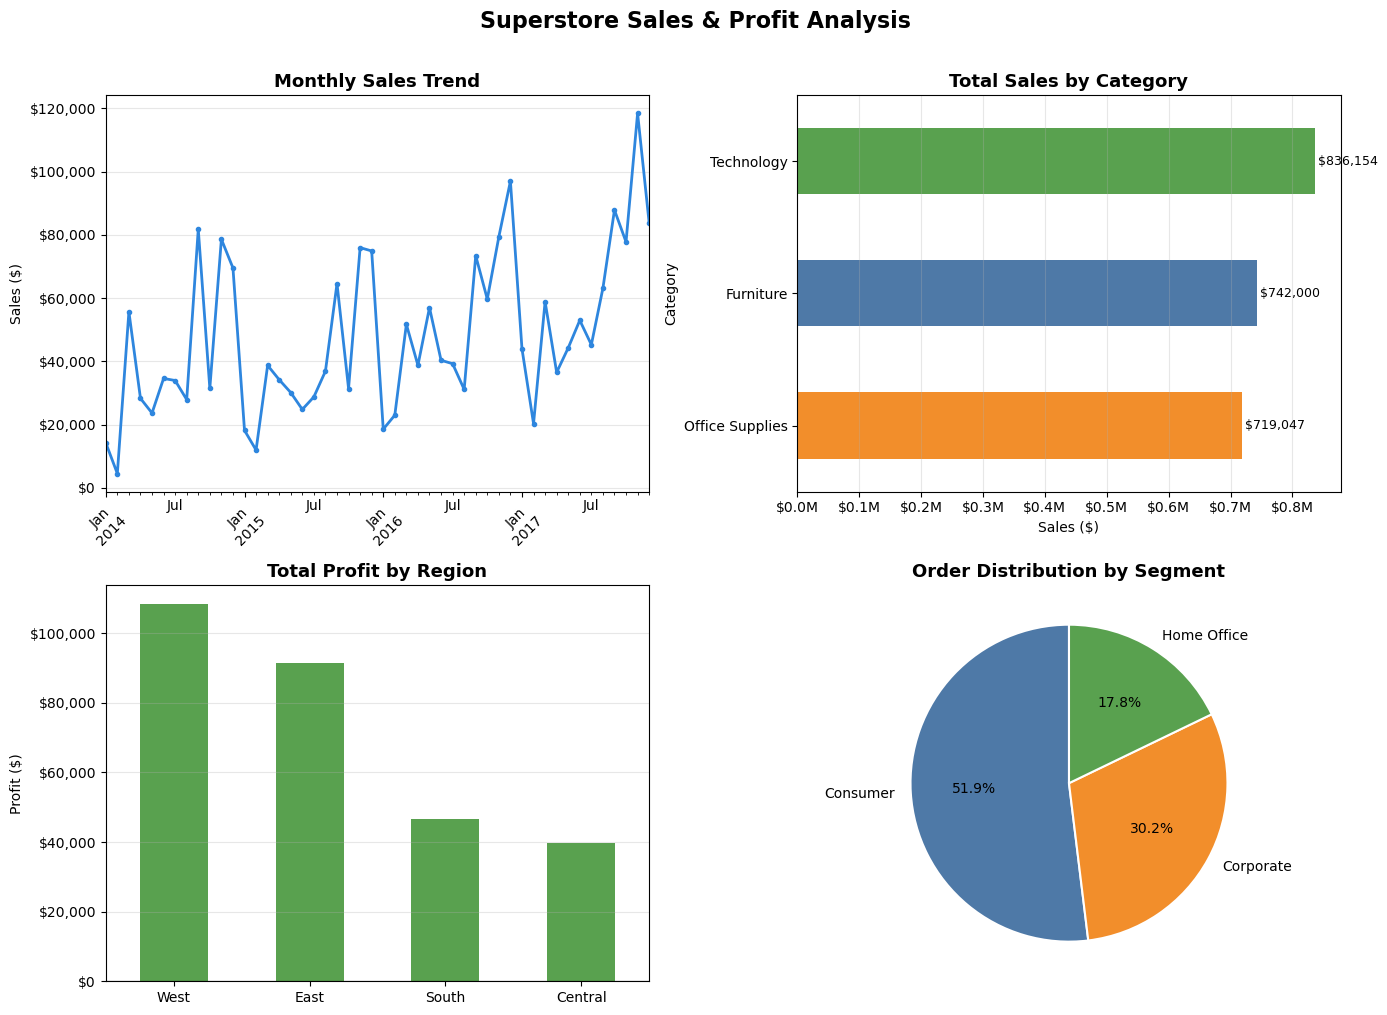

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superstore Sales & Profit Analysis', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Line chart: Monthly Sales Trend
monthly_sales = df.groupby('YearMonth')['Sales'].sum()
ax1 = axes[0, 0]
monthly_sales.plot(ax=ax1, kind='line', color='#2e86de', linewidth=2, marker='o', markersize=3)
ax1.set_title('Monthly Sales Trend', fontsize=13, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Sales ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# ── 2. Bar chart: Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values()
ax2 = axes[0, 1]
cat_sales.plot(ax=ax2, kind='barh', color=['#f28e2b', '#4e79a7', '#59a14f'])
ax2.set_title('Total Sales by Category', fontsize=13, fontweight='bold')
ax2.set_xlabel('Sales ($)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for i, v in enumerate(cat_sales):
    ax2.text(v + 5000, i, f'${v:,.0f}', va='center', fontsize=9)
ax2.grid(axis='x', alpha=0.3)

# ── 3. Bar chart: Profit by Region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
colors = ['#59a14f' if v >= 0 else '#e15759' for v in region_profit]
ax3 = axes[1, 0]
region_profit.plot(ax=ax3, kind='bar', color=colors)
ax3.set_title('Total Profit by Region', fontsize=13, fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Profit ($)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax3.tick_params(axis='x', rotation=0)
ax3.grid(axis='y', alpha=0.3)
ax3.axhline(0, color='black', linewidth=0.8)

# ── 4. Pie chart: Segment Distribution
segment_counts = df['Segment'].value_counts()
ax4 = axes[1, 1]
ax4.pie(segment_counts, labels=segment_counts.index,
        autopct='%1.1f%%', startangle=90,
        colors=['#4e79a7', '#f28e2b', '#59a14f'],
        wedgeprops={'edgecolor':'white', 'linewidth': 1.5})
ax4.set_title('Order Distribution by Segment', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('superstore_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insight:** The monthly trend shows clear seasonality — sales spike every Q4 (November–December). Technology and Furniture lead in total revenue. The West region is most profitable, while Central lags behind. Consumer segment makes up the majority (~51%) of all orders.

## Task 8: Key Insights & Conclusions

Summary of findings from the full analysis.

In [45]:
print("=" * 55)
print("  SUPERSTORE ANALYSIS — KEY FINDINGS")
print("=" * 55)

# Most profitable category
best_cat = df.groupby('Category')['Profit'].sum().idxmax()
best_cat_val = df.groupby('Category')['Profit'].sum().max()
print(f"\n1. Most profitable category: {best_cat}")
print(f"   Total profit: ${best_cat_val:,.0f}")

# Least performing region
worst_region = df.groupby('Region')['Profit'].sum().idxmin()
worst_val = df.groupby('Region')['Profit'].sum().min()
print(f"\n2. Least performing region: {worst_region}")
print(f"   Total profit: ${worst_val:,.0f}")

# Sales vs Profit correlation
corr = df[['Sales', 'Profit']].corr().loc['Sales', 'Profit']
print(f"\n3. Sales vs Profit correlation: {corr:.3f}")
print("   (1.0 = perfect, 0 = none, negative = inverse)")

# Seasonal trend
monthly_avg = df.groupby('Order Month')['Sales'].sum()
peak_month = monthly_avg.idxmax()
import calendar
print(f"\n4. Peak sales month: {calendar.month_name[peak_month]}")
print(f"   Average monthly sales: ${monthly_avg[peak_month]:,.0f}")

# Worst sub-category
worst_sub = df.groupby('Sub-Category')['Profit'].sum().idxmin()
worst_sub_val = df.groupby('Sub-Category')['Profit'].sum().min()
print(f"\n5. Most loss-making sub-category: {worst_sub}")
print(f"   Total loss: ${worst_sub_val:,.0f}")
print("\n" + "=" * 55)

  SUPERSTORE ANALYSIS — KEY FINDINGS

1. Most profitable category: Technology
   Total profit: $145,455

2. Least performing region: Central
   Total profit: $39,706

3. Sales vs Profit correlation: 0.479
   (1.0 = perfect, 0 = none, negative = inverse)

4. Peak sales month: November
   Average monthly sales: $352,461

5. Most loss-making sub-category: Tables
   Total loss: $-17,725

